# NDE inference comparison
Let's compare how using different trained NDEs can impact the final posterior

In [1]:
import numpy as np 
from tqdm import tqdm

import emcee
import torch
import optuna

In [2]:
from px2cosmo import fm as FM
from px2cosmo import util as UT

In [3]:
import corner as DFM
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

## load mock observations

In [4]:
omega_true = np.load("/Users/ch54662/data/px2cosmo/mock/omega_true.npy")
X_obs_z11 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z11.npy")
X_obs_z9 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z9.npy")
X_obs_z7 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z7.npy")

In [6]:
# z=11
_X_obs_z11 = torch.tensor(X_obs_z11[:,:2].astype(np.float32)).to('mps')
_sig_obs_z11 = torch.tensor(X_obs_z11[:,2:].astype(np.float32)).to('mps')
_log1pN_obs_z11 = torch.tensor(np.log1p(X_obs_z11.shape[0]).astype(np.float32)).to('mps')

# z=9
_X_obs_z9 = torch.tensor(X_obs_z9[:,:2].astype(np.float32)).to('mps')
_sig_obs_z9 = torch.tensor(X_obs_z9[:,2:].astype(np.float32)).to('mps')
_log1pN_obs_z9 = torch.tensor(np.log1p(X_obs_z9.shape[0]).astype(np.float32)).to('mps')

# z=7
_X_obs_z7 = torch.tensor(X_obs_z7[:,:2].astype(np.float32)).to('mps')
_sig_obs_z7 = torch.tensor(X_obs_z7[:,2:].astype(np.float32)).to('mps')
_log1pN_obs_z7 = torch.tensor(np.log1p(X_obs_z7.shape[0]).astype(np.float32)).to('mps')

## Test 1: Poisson likelihood

In [9]:
# load top 3 z=11 poisson likelihood
study = optuna.load_study(
    study_name='q_omegat_log1pN_z11', 
    storage='sqlite:////Users/ch54662/data/px2cosmo/mock/ndes/nde/q_omegat_log1pN_z11/q_omegat_log1pN_z11.db'
)

In [17]:
ntrials, losses = [], [] 
for trial in study.trials: 
    if trial.values is not None: 
        ntrials.append(trial.number)
        losses.append(trial.values[-1])

In [19]:
np.array(ntrials)[np.argsort(losses)]

array([30, 32,  4, 51, 22,  8, 10, 41, 38, 29, 21, 33,  3, 28, 44, 35, 36,
       14, 45, 39, 27, 15, 42, 20,  7, 25, 34, 26, 19, 13, 17,  9, 47, 46,
       43, 23, 53, 52, 11, 50,  1, 24, 31, 16, 48,  6,  2, 12, 37,  5, 18,
       40, 49,  0])

In [20]:
p_omegat_log1pN_z11_0 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_omegat_log1pN_z11/q_omegat_log1pN_z11.30.pt', weights_only=False)
p_omegat_log1pN_z11_1 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_omegat_log1pN_z11/q_omegat_log1pN_z11.32.pt', weights_only=False)
p_omegat_log1pN_z11_2 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_omegat_log1pN_z11/q_omegat_log1pN_z11.4.pt', weights_only=False)

In [7]:
def log_prior(omega): 
    alpha, beta, gamma, Muv_s, phi_amp = omega
    if -1.8 < alpha < -1.5 and -1.8 < beta < -1.2 and -0.4 < gamma < 0 and -22 < Muv_s < -18 and 1e-3 < phi_amp < 1e-2: 
        return 0.
    return -np.inf

In [31]:
bounds = np.array([[-1.8, -1.5], [-1.8, -1.2], [-0.4, 0.], [-22., -18.], [1e-3, 1e-2]])

def log_p_0(omega, silent=True): 
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # poisson term of the likelihood
    omega_t = UT.inv_cdf_transform(omega, bounds.T)
    _omega_t = torch.tensor(omega_t.astype(np.float32)).to('mps')
    return p_omegat_log1pN_z11_0.log_prob(_omega_t, _log1pN_obs_z11, norm_posterior=False).item()

def log_p_1(omega, silent=True): 
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # poisson term of the likelihood
    omega_t = UT.inv_cdf_transform(omega, bounds.T)
    _omega_t = torch.tensor(omega_t.astype(np.float32)).to('mps')
    return p_omegat_log1pN_z11_1.log_prob(_omega_t, _log1pN_obs_z11, norm_posterior=False).item()

def log_p_2(omega, silent=True): 
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # poisson term of the likelihood
    omega_t = UT.inv_cdf_transform(omega, bounds.T)
    _omega_t = torch.tensor(omega_t.astype(np.float32)).to('mps')
    return p_omegat_log1pN_z11_2.log_prob(_omega_t, _log1pN_obs_z11, norm_posterior=False).item()

def log_p_ensemble(omega, silent=True): 
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # poisson term of the likelihood
    omega_t = UT.inv_cdf_transform(omega, bounds.T)
    _omega_t = torch.tensor(omega_t.astype(np.float32)).to('mps')

    logp = (p_omegat_log1pN_z11_0.log_prob(_omega_t, _log1pN_obs_z11, norm_posterior=False).item() + 
            p_omegat_log1pN_z11_1.log_prob(_omega_t, _log1pN_obs_z11, norm_posterior=False).item() + 
            p_omegat_log1pN_z11_2.log_prob(_omega_t, _log1pN_obs_z11, norm_posterior=False).item())/3
    return logp

In [28]:
ndim, nwalkers = 5, 10
p0 = np.array([
    np.random.uniform(-1.8, -1.5, nwalkers),
    np.random.uniform(-1.8, -1.2, nwalkers),
    np.random.uniform(-0.4,  0.0, nwalkers),
    np.random.uniform(-22.,  -18., nwalkers),
    np.random.uniform(1e-3,  1e-2, nwalkers),
]).T

sampler0 = emcee.EnsembleSampler(nwalkers, ndim, log_p_0)
_ = sampler0.run_mcmc(p0, 10000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [02:05<00:00, 79.37it/s]


In [29]:
ndim, nwalkers = 5, 10
p0 = np.array([
    np.random.uniform(-1.8, -1.5, nwalkers),
    np.random.uniform(-1.8, -1.2, nwalkers),
    np.random.uniform(-0.4,  0.0, nwalkers),
    np.random.uniform(-22.,  -18., nwalkers),
    np.random.uniform(1e-3,  1e-2, nwalkers),
]).T

sampler1 = emcee.EnsembleSampler(nwalkers, ndim, log_p_1)
_ = sampler1.run_mcmc(p0, 10000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [02:04<00:00, 80.17it/s]


In [30]:
ndim, nwalkers = 5, 10
p0 = np.array([
    np.random.uniform(-1.8, -1.5, nwalkers),
    np.random.uniform(-1.8, -1.2, nwalkers),
    np.random.uniform(-0.4,  0.0, nwalkers),
    np.random.uniform(-22.,  -18., nwalkers),
    np.random.uniform(1e-3,  1e-2, nwalkers),
]).T

sampler2 = emcee.EnsembleSampler(nwalkers, ndim, log_p_2)
_ = sampler2.run_mcmc(p0, 10000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:48<00:00, 43.83it/s]


In [33]:
ndim, nwalkers = 5, 10
p0 = np.array([
    np.random.uniform(-1.8, -1.5, nwalkers),
    np.random.uniform(-1.8, -1.2, nwalkers),
    np.random.uniform(-0.4,  0.0, nwalkers),
    np.random.uniform(-22.,  -18., nwalkers),
    np.random.uniform(1e-3,  1e-2, nwalkers),
]).T

sampler_ens = emcee.EnsembleSampler(nwalkers, ndim, log_p_ensemble)
_ = sampler_ens.run_mcmc(p0, 10000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [07:34<00:00, 22.00it/s]


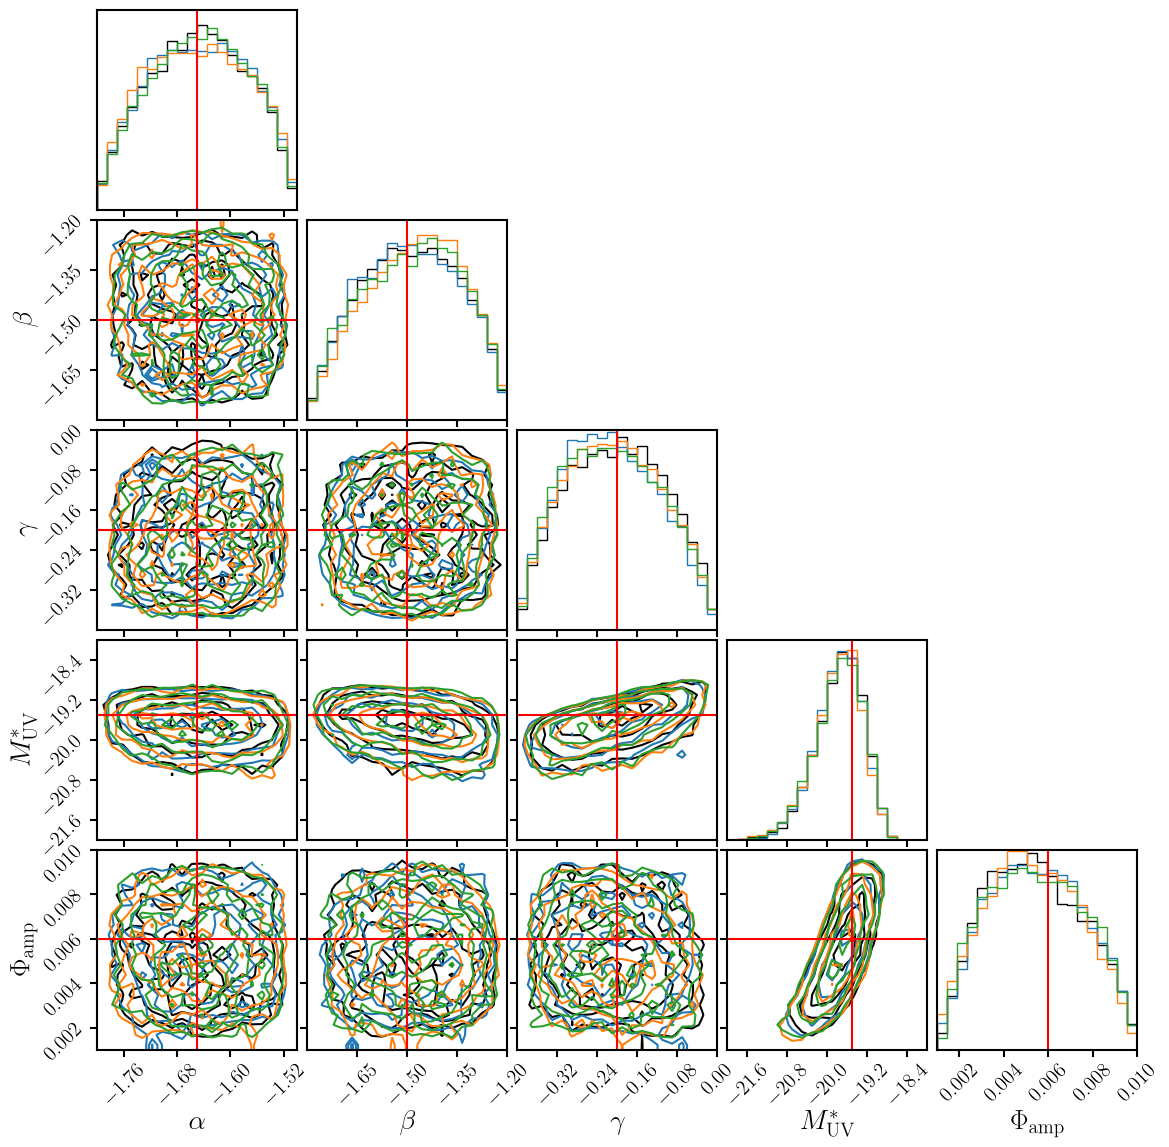

In [34]:
fig = DFM.corner(sampler_ens.flatchain[5000:,:], color='k', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
fig = DFM.corner(sampler0.flatchain[5000:,:], color='C0', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20},
                 fig=fig)
fig = DFM.corner(sampler1.flatchain[5000:,:], color='C1', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20},
                 fig=fig)
fig = DFM.corner(sampler2.flatchain[5000:,:], color='C2', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20}, 
                 fig=fig)

DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

virtually makes no difference. Cool. 

# Test 2: likelihood

In [35]:
# load top 3 z=11 NLEs
study = optuna.load_study(
    study_name='q_X_omegasig_z11', 
    storage='sqlite:////Users/ch54662/data/px2cosmo/mock/ndes/nde/q_X_omegasig_z11/q_X_omegasig_z11.db')

In [36]:
ntrials, losses = [], [] 
for trial in study.trials: 
    if trial.values is not None: 
        ntrials.append(trial.number)
        losses.append(trial.values[-1])

In [37]:
np.array(ntrials)[np.argsort(losses)]

array([20, 17,  2, 12, 15,  8, 11, 10, 21, 18, 13, 19,  4, 14,  7,  0, 16,
        6,  1,  5,  9,  3])

In [38]:
p_X_omegasig_S_z11_0 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_X_omegasig_z11/q_X_omegasig_z11.20.pt', weights_only=False)
p_X_omegasig_S_z11_1 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_X_omegasig_z11/q_X_omegasig_z11.17.pt', weights_only=False)
p_X_omegasig_S_z11_2 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_X_omegasig_z11/q_X_omegasig_z11.2.pt', weights_only=False)

In [41]:
def log_p_nle_0(omega, silent=True):
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # log likelihood
    _omega = torch.tensor(omega[:-1].astype(np.float32)).to('mps')
    _omegasig = torch.cat([_omega.expand(_X_obs_z11.shape[0], -1), _sig_obs_z11], dim=1)
    return p_X_omegasig_S_z11_0.log_prob_batched(_X_obs_z11, _omegasig, norm_posterior=False).sum().item()

def log_p_nle_1(omega, silent=True):
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # log likelihood
    _omega = torch.tensor(omega[:-1].astype(np.float32)).to('mps')
    _omegasig = torch.cat([_omega.expand(_X_obs_z11.shape[0], -1), _sig_obs_z11], dim=1)
    return p_X_omegasig_S_z11_1.log_prob_batched(_X_obs_z11, _omegasig, norm_posterior=False).sum().item()

def log_p_nle_2(omega, silent=True):
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # log likelihood
    _omega = torch.tensor(omega[:-1].astype(np.float32)).to('mps')
    _omegasig = torch.cat([_omega.expand(_X_obs_z11.shape[0], -1), _sig_obs_z11], dim=1)
    return p_X_omegasig_S_z11_2.log_prob_batched(_X_obs_z11, _omegasig, norm_posterior=False).sum().item()

def log_p_nle_ens(omega, silent=True):
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # log likelihood
    _omega = torch.tensor(omega[:-1].astype(np.float32)).to('mps')
    _omegasig = torch.cat([_omega.expand(_X_obs_z11.shape[0], -1), _sig_obs_z11], dim=1)
    logp = (p_X_omegasig_S_z11_0.log_prob_batched(_X_obs_z11, _omegasig, norm_posterior=False).sum().item()+ 
            p_X_omegasig_S_z11_1.log_prob_batched(_X_obs_z11, _omegasig, norm_posterior=False).sum().item()+
            p_X_omegasig_S_z11_2.log_prob_batched(_X_obs_z11, _omegasig, norm_posterior=False).sum().item())/3.
    return logp

In [40]:
ndim, nwalkers = 5, 10
p0 = np.array([
    np.random.uniform(-1.8, -1.5, nwalkers),
    np.random.uniform(-1.8, -1.2, nwalkers),
    np.random.uniform(-0.4,  0.0, nwalkers),
    np.random.uniform(-22.,  -18., nwalkers),
    np.random.uniform(1e-3,  1e-2, nwalkers),
]).T

sampler0 = emcee.EnsembleSampler(nwalkers, ndim, log_p_nle_0)
_ = sampler0.run_mcmc(p0, 10000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:22<00:00, 49.43it/s]


In [42]:
ndim, nwalkers = 5, 10
p0 = np.array([
    np.random.uniform(-1.8, -1.5, nwalkers),
    np.random.uniform(-1.8, -1.2, nwalkers),
    np.random.uniform(-0.4,  0.0, nwalkers),
    np.random.uniform(-22.,  -18., nwalkers),
    np.random.uniform(1e-3,  1e-2, nwalkers),
]).T

sampler1 = emcee.EnsembleSampler(nwalkers, ndim, log_p_nle_1)
_ = sampler1.run_mcmc(p0, 10000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [06:41<00:00, 24.90it/s]


In [43]:
ndim, nwalkers = 5, 10
p0 = np.array([
    np.random.uniform(-1.8, -1.5, nwalkers),
    np.random.uniform(-1.8, -1.2, nwalkers),
    np.random.uniform(-0.4,  0.0, nwalkers),
    np.random.uniform(-22.,  -18., nwalkers),
    np.random.uniform(1e-3,  1e-2, nwalkers),
]).T

sampler2 = emcee.EnsembleSampler(nwalkers, ndim, log_p_nle_2)
_ = sampler2.run_mcmc(p0, 10000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:31<00:00, 47.38it/s]


In [44]:
ndim, nwalkers = 5, 10
p0 = np.array([
    np.random.uniform(-1.8, -1.5, nwalkers),
    np.random.uniform(-1.8, -1.2, nwalkers),
    np.random.uniform(-0.4,  0.0, nwalkers),
    np.random.uniform(-22.,  -18., nwalkers),
    np.random.uniform(1e-3,  1e-2, nwalkers),
]).T

sampler_ens = emcee.EnsembleSampler(nwalkers, ndim, log_p_nle_ens)
_ = sampler_ens.run_mcmc(p0, 10000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [13:11<00:00, 12.64it/s]


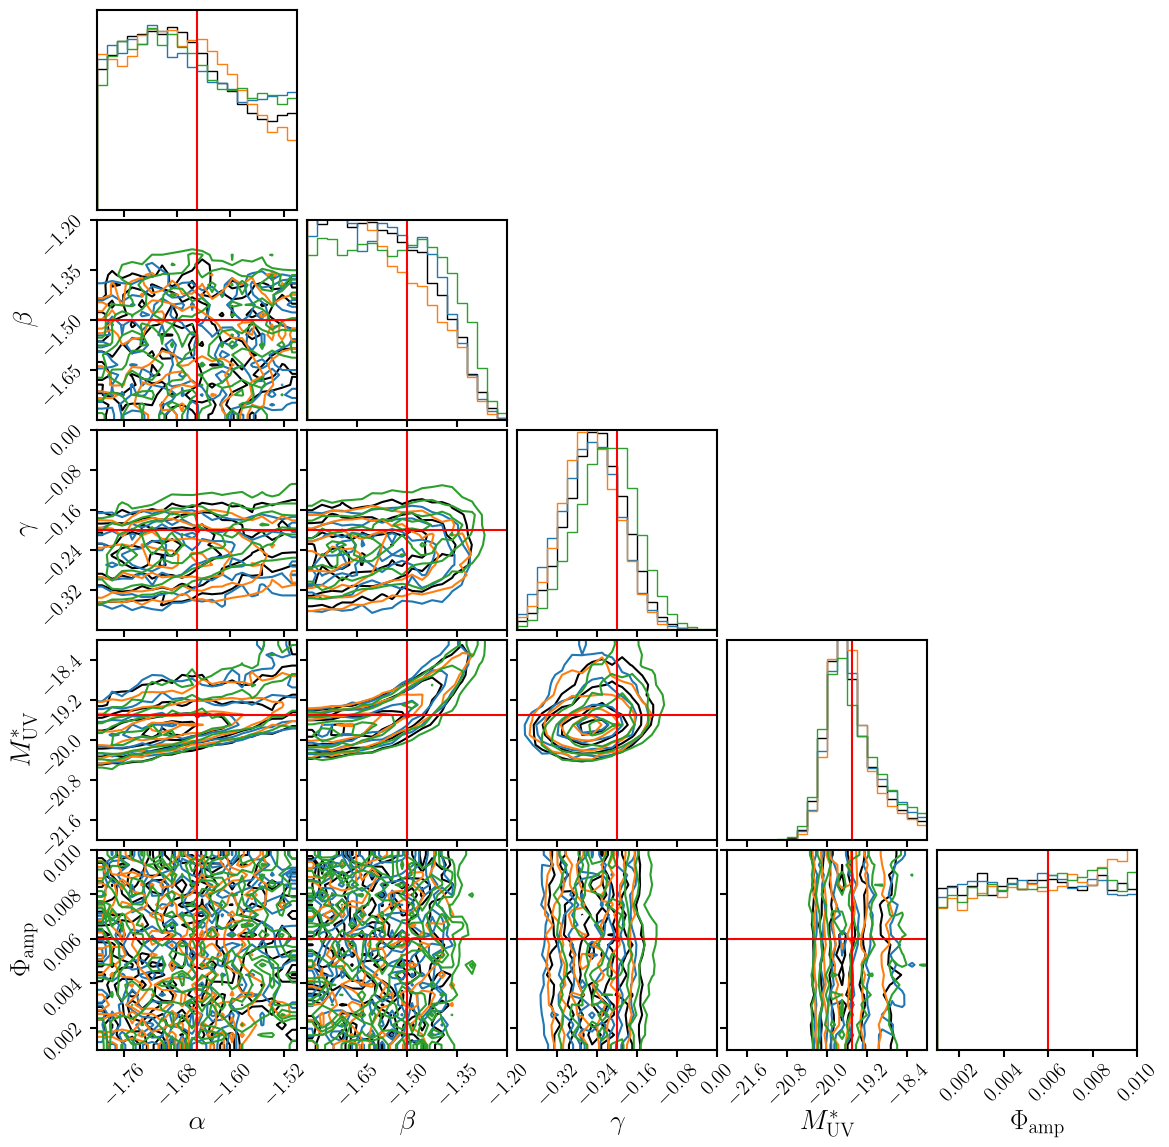

In [45]:
fig = DFM.corner(sampler_ens.flatchain[5000:,:], color='k', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
fig = DFM.corner(sampler0.flatchain[5000:,:], color='C0', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20},
                 fig=fig)
fig = DFM.corner(sampler1.flatchain[5000:,:], color='C1', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20},
                 fig=fig)
fig = DFM.corner(sampler2.flatchain[5000:,:], color='C2', plot_density=False, plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 hist_kwargs={'density': True}, 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20}, 
                 fig=fig)

DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

relatively small variational. Cool.